In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec

from scipy.constants import k
from scipy.special import k0
from dataclasses import dataclass

## Constants

In [2]:
pi = const.pi
h = const.h # J s
hbar = const.hbar # J s
e = const.e # C
k_B = const.k # J K-1

Phi_0 = const.physical_constants['mag. flux quantum'][0] #'Wb' h/(2e)

Ec= 0.233e9*h #J
C = e**2/(2*Ec) #F
T = 40e-3 #K


## Fluxonium Hamiltonian construction

In [3]:

def build_fluxonium_hamiltonians(
        EC: float,
        EJ: float,
        EL: float,
        flux: np.ndarray,
        phis: np.ndarray,
        ng: float,
) -> np.ndarray:

    # Phase grid
    phis = phis * 2*np.pi
    flux = flux*2*np.pi
    N = len(phis)

    # -----------------   Kinetic term (finite-difference Laplacian)
    delta_phi = phis[1] - phis[0]
    t = 1 / delta_phi**2

    n_op = 2 * t * np.eye(N) + 0j
    n_op += -t * np.exp(1j*0.5*ng*delta_phi) * np.eye(N, k=1)
    n_op += -t * np.exp(-1j*0.5*ng*delta_phi) * np.eye(N, k=-1)
    # periodic boundary conditions
    n_op += -t * np.exp(-1j*0.5*ng*delta_phi) * np.eye(N, k=N-1)
    n_op += -t * np.exp(1j*0.5*ng*delta_phi) * np.eye(N, k=-N+1)

    T = 4 * EC * n_op   # kinetic energy term
    
    # -------------  Potential term
    
    n = np.arange(0, 50)
    
    phi_grid = phis[None, :]                  # shape (1, N)
    flux_grid = flux[:, None] 

     # Initialize potential
    V = np.zeros((len(flux), N, N), dtype=float)
    
     # Potential energy at each phi for each flux
    V_phi = -EJ*np.cos(phi_grid - flux_grid) + 0.5*EL*phi_grid**2

    # Build diagonal potential matrices
    V = np.array([np.diag(v_row) for v_row in V_phi])   # shape (M, N, N)

    # Add kinetic energy
    H_all = V + T[None, :, :]   # shape (M, N, N)

    return H_all, V_phi, phis


In [4]:
def compute_transitions(H_all, levels):

    eigvals_all = []
    for H in H_all:
        eigvals, _ = np.linalg.eigh(H)
        eigvals_all.append(np.sort(np.real(eigvals)))
    eigvals_all = np.array(eigvals_all)  # shape (M, N_levels)

    freqs = {}
    for (i, j) in levels:
        freqs[(i, j)] = eigvals_all[:, j] - eigvals_all[:, i]
    return freqs, eigvals_all


## Calculate matrix elements

In [5]:
def compute_qubit_properties(EC, EJ, EL, phi, flux, ng, n_max=50):
    
    # Build Hamiltonians
    H_all, V_phi, phis = build_fluxonium_hamiltonians(
                                            EC=EC, EJ=EJ, EL=EL,
                                            phis=phi, flux=flux, ng = 0,
                                                )
    N = len(phis)
    # Phase grid
    
#     phis = phis * 2*np.pi
    flux = flux*2*np.pi
    
    phi_grid = phis[None, :]
    flux_grid = flux[:, None]

    # -----------   Derivative flux operator -----------
    
    d_H_d_flux = -2*np.pi*EJ* np.sin(phi_grid - flux_grid)
    

    # -------------- calculating flux and charge matrix element, extracting, qp_noise, f01---------------
        # Charge operator
    delta_phi = phis[1] - phis[0]
    n_op = n_operator_phase(N, delta_phi)
    
    # Phase operator
    phi_op = np.diag(phis)
    
    # Quasiparticle operator
    qp_op = np.diag(np.cos(phis/2)) # independent of flux


    freqs_01 = []
    n01_mod_sq_list = []
    phi01_mod_sq_list = []
    flux_noise_mod_sq_list = []
    qp01_mod_sq_list = []

    for i, H in enumerate(H_all):
        
        eigvals, evecs = np.linalg.eigh(H)

        eigvals = np.sort(np.real(eigvals))
        f01 = eigvals[1] - eigvals[0]
        freqs_01.append(f01)

        n_eigen = evecs.conj().T @ n_op @ evecs
        n01 = n_eigen[0,1]
        n01_mod_sq = np.abs(n01)**2
        n01_mod_sq_list.append(n01_mod_sq)
        
        phi_eigen = evecs.conj().T @ phi_op @ evecs
        phi_01 = phi_eigen[0,1]
        phi_01_mod_sq = np.abs(phi_01)**2
        phi01_mod_sq_list.append(phi_01_mod_sq) 
        
        d_H_d_flux_op = np.diag(d_H_d_flux[i])
        flux_noise_eigen = evecs.conj().T @ d_H_d_flux_op @ evecs
        flux_noise_01 = flux_noise_eigen[0,1]
        mod_sq_flux_noise_01 = np.abs(flux_noise_01)**2
        flux_noise_mod_sq_list.append(mod_sq_flux_noise_01)

        qp_eigen = evecs.conj().T @ qp_op @ evecs
        qp01 = qp_eigen[0,1]
        qp01_mod_sq = np.abs(qp01)**2
        qp01_mod_sq_list.append(qp01_mod_sq) 

    n01_mx = np.array(n01_mod_sq_list)
    phi01_mx = np.array(phi01_mod_sq_list)
    flux_01_mx = np.array(flux_noise_mod_sq_list)
    qp01_mx = np.array(qp01_mod_sq_list)

    f01 = np.array(freqs_01)

    
    return (f01, n01_mx, phi01_mx, flux_01_mx, qp01_mx)


In [6]:
def n_operator_phase(N, delta_phi, ng=0.0):
    # central finite difference for derivative
    t = 1 / (2 * delta_phi)
    n_op = np.zeros((N, N), dtype=complex)
    
    # off-diagonal elements
    for i in range(N-1):
        n_op[i, i+1] = -1j * t
        n_op[i+1, i] = 1j * t
    
    # periodic boundary
    n_op[0, -1] = 1j * t
    n_op[-1, 0] = -1j * t
    
    # offset by ng
    n_op -= ng * np.eye(N)
    
    return n_op

## Noise computation

### Dielectric loss

In [7]:
def Charge_noise(EC, f01, n01, A_cap, alpha_cap):
    
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)
    
    CJ = e**2 / (2 * EC * 1e9 * h)

    Q_cap = A_cap * (6/f01)**(alpha_cap)
    S_cap =  hbar / (CJ * Q_cap) *(coth)

    Gamma_cap = hbar**(-2) * n01 * S_cap * (2 * e)**2
    
    return Gamma_cap


### FBL noise

In [ ]:
def FBL_noise_mix(f01, flux_mx, M):
    # To convert the mutual inductance to Henries in this formula, an additional
    # Phi_0 factor would normally appear. However, this factor cancels with the
    # Phi_0 contained in the matrix element during the transition-rate calculation.
    # Since Phi_0 is omitted from the matrix-element calculation here, it is also
    # omitted from the mutual inductance definition.
    
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)
    
    R = 50

    coef = (h * 1e9)**2 # To convert to energy from GHz

    S_flux_line = (M**2*omega01*hbar/R)*coth

    Gamma_flux_line = (1 / hbar**2)* coef * flux_mx * S_flux_line

    return Gamma_flux_line


### $1/f$ noise

In [ ]:
def one_over_f_noise(f01, flux_mx, A_lambda, gamma_1_f):
    # Phi_0 cancels in the transition-rate calculation through the product of the
    # noise quality factor and matrix element, so neither the noise operator nor
    # the A_lambda coefficient includes Phi_0.


    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    S_lambda = 2*np.pi*A_lambda**2/(omega01)**gamma_1_f

    flux_noise_total = flux_mx

    coef = (h * 1e9)**2 

    Gamma_one_over_f =  (1 / hbar**2) * coef * flux_noise_total *  S_lambda 
    
    return Gamma_one_over_f 

### Inductive noise

In [10]:
def Inductive_noise(EJ, f01, phi_op, A_ind):
    
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (2*k_B * T)
    coth = 1 / np.tanh(0.5 * therm_ratio)

    omega_ref = 2 * np.pi * 0.5e9  # rad/s
    arg_ref = hbar * omega_ref / (2 * k_B * T)                                  

    Q_ind = A_ind * (k0(arg_ref) * np.sinh(arg_ref)) / (k0(therm_ratio) * np.sinh(therm_ratio))
    
    LJ = (Phi_0/(2*np.pi))**2/(EJ*h*1e9)

    coeff = ((Phi_0)/(2*np.pi))**2
                                      
    B_lambda_sq = coeff*phi_op

    # Spectral density S(ω)
    S_ind = hbar / (LJ * Q_ind) * (coth)                                              
                                          
    Gamma_ind = hbar**(-2)*S_ind*B_lambda_sq
    
    return Gamma_ind


### QP noise

In [11]:
def QP_noise(EJ, qp_op, f01, x_qp):
    
    omega01 = 2 * np.pi * f01 * 1e9  # Convert GHz to rad/s

    therm_ratio = hbar * omega01 / (2*k_B * T)
    coth = 1 / np.tanh(therm_ratio)

    Delta = 3.4e-4 * e  

    Rk = h/e**2
    prefactor = np.sqrt(2/np.pi)
    
    energy_ratio = (8*EJ*1e9*h/(Rk*Delta))
    
    gap_term = (2*Delta/(hbar*omega01))**(3/2)

    ReY = x_qp*prefactor*energy_ratio*gap_term*np.sqrt(therm_ratio)*k0(therm_ratio)*np.sinh(therm_ratio)
    
    S_qp = hbar*omega01*ReY*(1+coth)
    
    Gamma_qp =  2*(Phi_0/(hbar*np.pi))**2*qp_op*S_qp
    
    return Gamma_qp


### Purcell decay

In [29]:
def simple_Purcell(f01,  n01, f_res, g):

    Q_L = 4.6e4

    Delta = 2 * np.pi *(f01 - f_res) * 1e9  # Hz

    kappa = 2 * np.pi * f_res* 1e9 / Q_L  # Hz
    
    Gamma_purcell = (g**2*n01* kappa) / (Delta**2)
    
    return Gamma_purcell

## Spectrum and T1 computation

In [13]:
def compute_fluxonium_spectrum(
    EC, EJ, EL,
    phi,
    phi_ext,
    ng,
    dim,
    levels):

    # Build Hamiltonian
    H_all, V_phi, phis = build_fluxonium_hamiltonians(
        EC=EC, EJ=EJ, EL=EL,
        phis=phi,
        flux=phi_ext,
        ng=ng
    )

    # Diagonalize
    evals, evecs = np.linalg.eigh(H_all)

    # Scale for visualization
    psi_scale = 0.8 * np.abs(evals).max() / dim

    # Compute transitions
    freqs, eigvals_all = compute_transitions(H_all, levels)

    return {
        "H": H_all,
        "V_phi": V_phi,
        "phis": phis,
        "evals": evals,
        "evecs": evecs,
        "freqs": freqs,
        "psi_scale": psi_scale
    }

In [30]:
def run_qubit_calculation(
        EJ, EL, EC, ng, n_max,
        noise,
        phi_ext):

    # Prepare flux grids
    # phi = np.linspace(0, 1, 151)
    # phi_ext = np.linspace(*phi_ext_range, phi_samples)

    # Compute qubit parameters
    f01, n01_mx, phi01_mx, flux_01_mx, qp01_mx = compute_qubit_properties(EC= EC, EJ = EJ, EL = EL, phi = phi,
                                                                           flux = phi_ext, ng = ng, n_max=n_max)

    # Individual channels
    Gamma_charge_noise = Charge_noise(EC, f01, n01_mx,  A_cap=noise.A_cap, alpha_cap=noise.alpha_cap)

    Gamma_ind_noise = Inductive_noise(EJ, f01, phi01_mx, A_ind=noise.A_ind)

    Gamma_flux_line = FBL_noise_mix(f01, flux_01_mx, M=noise.M)

    Gamma_qp = QP_noise(EJ, qp01_mx, f01, x_qp=noise.x_qp)

    Gamma_one_over_f =  one_over_f_noise(f01, flux_01_mx,  A_lambda=noise.A_lambda,
            gamma_1_f=noise.gamma_1_f)

    Gamma_purcell = simple_Purcell(f01, n01_mx, f_res, g = noise.g)

        # Total relaxation time
    T1_total = 1/(Gamma_charge_noise + Gamma_flux_line + Gamma_purcell + Gamma_one_over_f)

    return {
        "phi_ext": phi_ext,
        "T1_total": T1_total,
        "Gamma_components": {
            "flux_ohmic": Gamma_flux_line,
            "charge": Gamma_charge_noise,
            "purcell": Gamma_purcell,
            "one_over_f": Gamma_one_over_f,
            "inductive": Gamma_ind_noise,
            "qp": Gamma_qp
        }
    }

## Plotting functions 

In [31]:
def plot_transitions(results, phi_ext, ax=None, colors=None):
    rs = results
    freqs = rs["freqs"]

    if ax is None:
        ax = plt.gca()

    for key, f in freqs.items():
        if colors and key in colors:
            color = colors[key]
        else:
            color = None  # use default color cycle
        ax.plot(phi_ext, f, label=fr"$f_{{{key[0]}{key[1]}}}$", color=color)

    ax.set_xlabel(r" $\Phi_{ext}/\Phi_0$")
    ax.set_ylabel("Freq. (GHz)")
    ax.legend()

In [32]:
def plot_phase_basis_stack(results, flux, dashed_levels=None, ax=None):

    flux_index = np.argmin(np.abs(phi_ext - flux))
    
    rs = results
    evals = rs["evals"][flux_index]
    evecs = rs["evecs"][flux_index]
    V_phi = rs["V_phi"][flux_index]
    phis = rs["phis"]
    psi_scale = rs["psi_scale"]


    
    if ax is None:
        ax = plt.gca()
    if dashed_levels is None:
        dashed_levels = []

    phis = phis/ (2*np.pi)

    E0 = evals[0]
    evals -= E0

    ax.plot(phis, V_phi - E0, color='gray', lw=2, ls='--', label=rf"$U(\varphi)$")

    for i in range(4):
        linestyle = "-." if i in dashed_levels else "-"
        psi = evecs[:, i]

        color = even_colors[i] if i % 2 == 0 else odd_colors[i]

        ax.plot(
            phis,
            evals[i] + psi * psi_scale,
            lw=2,
            ls=linestyle,
            color=color,
            label=rf"$\psi_{i}$"
        )

    ax.set_xlabel(r"Phase $\phi / 2\pi$")
    ax.set_ylabel("Energy (GHz)")
    ax.legend()

In [33]:
def plot_dataset_noises(results, ax, show_ylabel=False):
        lw = 2
        r = results
        G = r["Gamma_components"]
        
        ax.set_yscale('log')
        ax.set_xlim(0, 1)

        ax.plot(phi_ext, r["T1_total"] * 1e6, lw=lw, label=r'$T_1$ total', color = Total_T1_color)

        ax.plot(phi_ext, 1 / G["flux_ohmic"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[2], label="Ohmic flux noise")
        ax.plot(phi_ext, 1 / G["one_over_f"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[3], label=r"$1/f$ flux noise")
        ax.plot(phi_ext, 1 / G["inductive"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[4], label="Inductive noise")
        ax.plot(phi_ext, 1 / G["charge"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[0], label="Dielectric loss")
        ax.plot(phi_ext, 1 / G["purcell"] * 1e6,
                '--', lw=1.5, color=T1_noise_colors[1], label="Purcell decay")
        # ax.plot(phi_ext, 1 / G["qp"] * 1e6,
        #         '--', lw=1.5, color=T1_noise_colors[5], label="QP noise")
        
        ax.legend()
        ax.set_ylim(ymin=10e-0, ymax=10e5)
        ax.set_ylim(ymin=0.4, ymax=0.6)
        ax.set_yticks([1e-1, 1e0, 1e2, 1e4])
        # ax.set_title(rf"$\varphi_{{ext_2}} = {dataset_key}$")
        ax.set_xlabel(r'$\Phi_{ext}/\Phi_0$')

        
        ax.set_ylabel(r"$T_1$ ($\mu$s)")
  

In [34]:

def plot_results():
    fig = plt.figure(figsize=(3.40457, 3.8))

    gs = gridspec.GridSpec(
        2, 2,
        figure=fig,
        height_ratios=[1, 1.6],  # bottom plot bigger
        hspace=0.35,
        wspace=0.75
    )

    # --- Axes layout ---
    ax_tl = fig.add_subplot(gs[0, 0])   # top-left
    ax_tr = fig.add_subplot(gs[0, 1])   # top-right
    ax_bl = fig.add_subplot(gs[1, :])   # bottom (spans both columns)

    # ---- Top-left plot ----
    plot_transitions(results_spectrum, phi_ext, ax=ax_tl, colors=colors)
    ax_tl.legend(loc='upper left')
    ax_tl.legend(
        loc='center left',
        bbox_to_anchor=(-0.11, 1.2),
        frameon=False, 
         ncol=2,  
        handlelength=1.65,
        columnspacing=0.8,
    )
    top_ticks = [0.1, 2, 4, 6]

    # Left column
    ax_tl.set_yticks(top_ticks)
    ax_tl.set_yticklabels(top_ticks)  # show labels
    ax_tl.yaxis.set_tick_params(labelleft=True)
    ax_tl.set_ylim(None, 6.5)
    # ax_tl.set_xlim(0.4, 0.6)


    # ---- Top-right plot ----
    plot_phase_basis_stack(results_spectrum, flux=flux_ext_point, dashed_levels=[1, 3], ax=ax_tr)
    ax_tr.set_xlim(-1, 1)
    ax_tr.set_ylim(-5, 20)
    handles, labels = ax_tr.get_legend_handles_labels()

    # First legend (single item)
    leg1 = ax_tr.legend(
        [handles[0]], [labels[0]],
        loc='center left',
        bbox_to_anchor=(-0.45, 1.22),
        frameon=False,
        handlelength=1.65
    )

    # Second legend (rest, 2 columns)
    leg2 = ax_tr.legend(
        handles[1:], labels[1:],
        loc='center left',
        bbox_to_anchor=(0.22, 1.2),
        ncol=2,
        frameon=False,
        columnspacing=0.8,
        handlelength=1.65
    )

    # Important: keep both legends
    ax_tr.add_artist(leg1)
    # ---- Bottom (big) plot ----
    plot_dataset_noises(results_T1, ax_bl)
    ax_bl.set_xlabel(r"$\Phi_{ext}/\Phi_0$")

    ax_bl.legend(
    loc='upper center',
    bbox_to_anchor=(0.45, -0.25),  # below the axis
    ncol=3,                       # 3 columns
    frameon=False,
    handlelength=1.65
    )

    panel_labels = ['(a)', '(b)',  ]
    for ax, label in zip([ax_tl, ax_tr], panel_labels):
        ax.text(-0.6, 1.1, label, transform=ax.transAxes,
            fontweight='bold', ha='left', va='top')
        
    panel_labels = ['(c)']
    for ax, label in zip([ax_bl], panel_labels):
        ax.text(-0.225, 1.1, label, transform=ax.transAxes,
            fontweight='bold', ha='left', va='top')

    fig.savefig("Fig5_Fluxonium.pdf", dpi=1200, bbox_inches='tight')
    # fig.savefig("Fluxonium.svg", dpi=1200, bbox_inches='tight')
    plt.show()


## Visualization

In [35]:
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

plt.rcParams.update({
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})


levels = [(0, 1), (0, 2), (1, 2), (0, 3)]

f01_cmap = mpl.colormaps['Blues']
f01_colors = f01_cmap(np.linspace(0.4, 0.95, 3))

colors = {
    (0,1): "#38610C",         # 01 transition in blue
    (0,2): "#65863F",      # 02 in brown
    (1,2): "#64305C",
    (0,3): "#8EAA70",      # 12 in lighter brown
}



Total_T1_color = "#e79c2b"


T1_noise_colors = [
    "#0e469b",
    "#1076ca", 
    "#086814",  
    "#7ac009",  
    "#9c9208", 
    "#27b3c5", 
  # purple
]


even_cmap = mpl.colormaps['Oranges']
odd_cmap  = mpl.colormaps['Purples']

even_colors = {
    0: even_cmap(0.65),
    2: even_cmap(0.85),
}

odd_colors = {
    1: odd_cmap(0.65),
    3: odd_cmap(0.9),
}

## System parameters

In [36]:
EC = 1
EJ = 4.1
EL = 0.8

f_res = 5.2344 #GHz

ng = 0.0
n_max = 50
ncut = 50
dim = 2 * ncut + 1


phi = np.linspace(-1, 1, 151)
phi_ext = np.linspace(0, 1, 151)

flux_ext_point = 0.5

@dataclass
class NoiseParams:
    x_qp: float = 7e-10
    A_cap: float = 1e5
    alpha_cap: float = 0.7
    M: float = 1800
    A_ind: float = 5e8
    g: float = 25e6
    A_lambda: float = 1.5e-5
    gamma_1_f: float = 1.0

noise = NoiseParams

## Main computation

In [37]:
results_spectrum = compute_fluxonium_spectrum(
    EC=EC,
    EJ=EJ,
    EL=EL,
    phi=phi,
    phi_ext=phi_ext,
    ng=ng,
    dim=dim, 
    levels = levels
)

results_T1 = run_qubit_calculation(EC= EC,
                                   EJ = EJ,
                                   EL = EL,
                                   ng=ng,
                                   n_max=n_max,
                                   noise=noise,
                                   phi_ext=phi_ext
                                    )

## Plotting

c:\Users\nzhurbina\AppData\Local\anaconda3\envs\gatemon\Lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\nzhurbina\AppData\Local\anaconda3\envs\gatemon\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


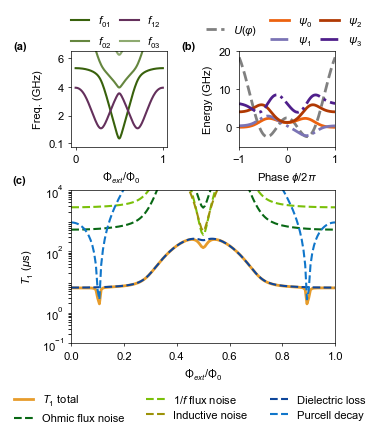

In [38]:
plot_results()

In [28]:
rt = results_T1
G = rt["Gamma_components"]
T1_total = rt["T1_total"]

rs = results_spectrum
freqs = rs["freqs"]

phi_target = 0.5

# Interpolate each curve at phi_ext = 0.5
T1_total_at_sweet_spot = np.interp(phi_target, phi_ext, T1_total)
f01_at_sweet_spot = np.interp(phi_target, phi_ext, freqs[(0, 1)])


print(f"T1_total at phi_ext=0.5: {T1_total_at_sweet_spot*1e6:.2f} µs")
print(f"f01 at phi_ext=0.5: {f01_at_sweet_spot:.4f} GHz")

T1_total at phi_ext=0.5: 132.45 µs
f01 at phi_ext=0.5: 0.4016 GHz
